Adding t50 to the dataset

Define t50 relative to the event’s own peak, not an absolute level.
threshold = 0.5 * max(outageFraction for that event)
don’t change t90 now. Yes, they are defined differently—that’s fine.
t90 is defined as recovery to near-complete restoration (10% outage), which is standard.
For earlier-stage recovery, a fixed 50% threshold is not appropriate because many events never reach that level. Instead, we define t50 relative to each event’s peak outage, so it represents “half recovery” consistently across storms.

In [1]:
2

2

In [2]:
import pandas as pd
import numpy as np

# Paths (from your previous work)
ts_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_timeseries_clean.parquet"
rf_v4_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v4_gdp.csv"

# Load
ts_df = pd.read_parquet(ts_path)
rf_v4_df = pd.read_csv(rf_v4_path)

# Ensure types
ts_df["CountyFIPS"] = ts_df["CountyFIPS"].astype(str).str.zfill(5)
rf_v4_df["CountyFIPS"] = rf_v4_df["CountyFIPS"].astype(str).str.zfill(5)

ts_df["datetime"] = pd.to_datetime(ts_df["datetime"])
ts_df["event_start"] = pd.to_datetime(ts_df["event_start"])

print("Time series shape:", ts_df.shape)
print("RF_v4 shape:", rf_v4_df.shape)

Time series shape: (16918, 12)
RF_v4 shape: (90, 19)


In [3]:
def last_downward_transition(g, threshold):
    g = g.sort_values("datetime").copy()
    start = g["event_start"].iloc[0]

    post = g[g["datetime"] >= start].copy()
    y = post["outage_clean"].to_numpy(dtype=float)
    t = post["datetime"].to_numpy()

    if len(y) < 2:
        return None, 0.0, 1

    above_to_below = (y[:-1] > threshold) & (y[1:] <= threshold)
    idx = np.where(above_to_below)[0]

    if len(idx) == 0:
        return None, g["duration_hours"].max(), 1

    i = idx[-1]  # last crossing
    y0, y1 = y[i], y[i + 1]
    t0 = pd.Timestamp(t[i])
    t1 = pd.Timestamp(t[i + 1])

    if y0 == y1:
        cross_time = t1
    else:
        frac = (y0 - threshold) / (y0 - y1)
        cross_time = t0 + (t1 - t0) * frac

    t_hours = (cross_time - start) / pd.Timedelta(hours=1)
    return cross_time, float(t_hours), 0

In [4]:
rows = []

group_cols = ["event_id", "CountyFIPS"]

for (event_id, county_fips), g in ts_df.groupby(group_cols):
    g = g.sort_values("datetime").copy()
    start = g["event_start"].iloc[0]

    post = g[g["datetime"] >= start]

    # --- t90 (absolute threshold) ---
    _, t90, cens90 = last_downward_transition(g, threshold=0.1)

    # --- t50 (relative threshold) ---
    peak = post["outage_clean"].max()
    
    if pd.isna(peak) or peak <= 0:
        t50 = np.nan
        cens50 = 1
    else:
        threshold_50 = 0.5 * peak
        _, t50, cens50 = last_downward_transition(g, threshold=threshold_50)

    rows.append({
        "event_id": event_id,
        "CountyFIPS": county_fips,
        "t90_new": t90,
        "t90_censored_new": cens90,
        "t50": t50,
        "t50_censored": cens50,
    })

targets_df = pd.DataFrame(rows)

print("Targets shape:", targets_df.shape)
print(targets_df.head())

Targets shape: (90, 6)
                            event_id CountyFIPS     t90_new  t90_censored_new  \
0  2017212N28275_2017-07-30 21:00:00      12075    1.885185                 0   
1  2017242N16333_2017-09-09 19:00:00      12037  120.406155                 0   
2  2017242N16333_2017-09-09 20:00:00      12067  186.802564                 0   
3  2017242N16333_2017-09-09 21:00:00      12013   52.651220                 0   
4  2017242N16333_2017-09-09 22:00:00      12075  170.764203                 0   

          t50  t50_censored  
0    1.500000             0  
1  120.428195             0  
2  101.994455             0  
3   51.934783             0  
4   97.618621             0  


In [5]:
rows = []

group_cols = ["event_id", "CountyFIPS"]

for (event_id, county_fips), g in ts_df.groupby(group_cols):
    g = g.sort_values("datetime").copy()
    start = g["event_start"].iloc[0]

    post = g[g["datetime"] >= start]

    # --- t90 (absolute threshold) ---
    _, t90, cens90 = last_downward_transition(g, threshold=0.1)

    # --- t50 (relative threshold) ---
    peak = post["outage_clean"].max()
    
    if pd.isna(peak) or peak <= 0:
        t50 = np.nan
        cens50 = 1
    else:
        threshold_50 = 0.5 * peak
        _, t50, cens50 = last_downward_transition(g, threshold=threshold_50)

    rows.append({
        "event_id": event_id,
        "CountyFIPS": county_fips,
        "t90_new": t90,
        "t90_censored_new": cens90,
        "t50": t50,
        "t50_censored": cens50,
    })

targets_df = pd.DataFrame(rows)

print("Targets shape:", targets_df.shape)
print(targets_df.head())

Targets shape: (90, 6)
                            event_id CountyFIPS     t90_new  t90_censored_new  \
0  2017212N28275_2017-07-30 21:00:00      12075    1.885185                 0   
1  2017242N16333_2017-09-09 19:00:00      12037  120.406155                 0   
2  2017242N16333_2017-09-09 20:00:00      12067  186.802564                 0   
3  2017242N16333_2017-09-09 21:00:00      12013   52.651220                 0   
4  2017242N16333_2017-09-09 22:00:00      12075  170.764203                 0   

          t50  t50_censored  
0    1.500000             0  
1  120.428195             0  
2  101.994455             0  
3   51.934783             0  
4   97.618621             0  


In [6]:
merged_df = rf_v4_df.merge(
    targets_df,
    on=["event_id", "CountyFIPS"],
    how="inner"
)

print("Merged shape:", merged_df.shape)
print(merged_df.head())

Merged shape: (90, 23)
                            event_id          storm CountyFIPS         t90  \
0  2017212N28275_2017-07-30 21:00:00  2017212N28275      12075    1.885185   
1  2017242N16333_2017-09-09 19:00:00  2017242N16333      12037  120.406155   
2  2017242N16333_2017-09-09 20:00:00  2017242N16333      12067  186.802564   
3  2017242N16333_2017-09-09 21:00:00  2017242N16333      12013   52.651220   
4  2017242N16333_2017-09-09 22:00:00  2017242N16333      12075  170.764203   

   t90_censored   max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  \
0             0  12.601287      7.421799        67.413998      1009.864246   
1             0  27.279316     12.005697        92.750718       995.318712   
2             0  33.241034      9.333728       153.916280       982.833530   
3             0  25.291777     14.104932        89.230104       996.010565   
4             0  33.169058      9.553964       145.733609       976.919507   

   max_customers_tracked  ...  matched_

In [7]:
if "t90" in merged_df.columns:
    diff = np.abs(merged_df["t90"] - merged_df["t90_new"])

    print("\nT90 validation:")
    print("Mean abs diff:", diff.mean())
    print("Max abs diff:", diff.max())

    print("\nWorst 5 differences:")
    print(
        merged_df.loc[diff.nlargest(5).index,
        ["event_id", "CountyFIPS", "t90", "t90_new"]]
    )
else:
    print("No existing t90 column found for validation.")


T90 validation:
Mean abs diff: 4.421154800285068e-15
Max abs diff: 5.684341886080802e-14

Worst 5 differences:
                             event_id CountyFIPS         t90     t90_new
53  2018280N18273_2018-10-10 15:00:00      12045  439.371951  439.371951
6   2017242N16333_2017-09-10 06:00:00      12011  153.046806  153.046806
19  2017242N16333_2017-09-10 22:00:00      12055  216.544517  216.544517
28  2017242N16333_2017-09-11 01:00:00      12083  170.845032  170.845032
49  2017242N16333_2017-09-11 22:00:00      12043  209.937500  209.937500


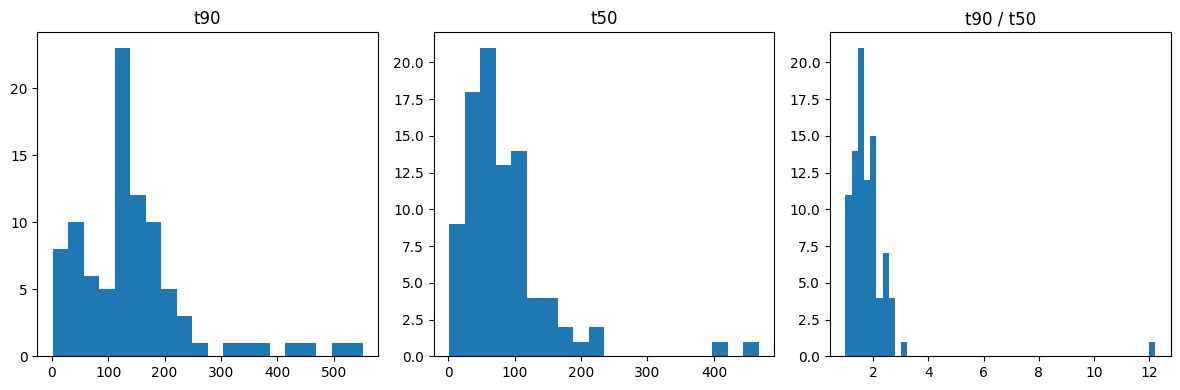

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(merged_df["t90_new"], bins=20)
plt.title("t90")

plt.subplot(1,3,2)
plt.hist(merged_df["t50"], bins=20)
plt.title("t50")

plt.subplot(1,3,3)
plt.hist(merged_df["t90_new"] / merged_df["t50"], bins=50)
plt.title("t90 / t50")

plt.tight_layout()
plt.show()

In [9]:
save_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v5_t50.csv"

merged_df.to_csv(save_path, index=False)

print("Saved dataset to:", save_path)
print(merged_df.shape)

Saved dataset to: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v5_t50.csv
(90, 23)


**---- That dataset above is the most important part. Below is some plots, and then some modelling. ----**

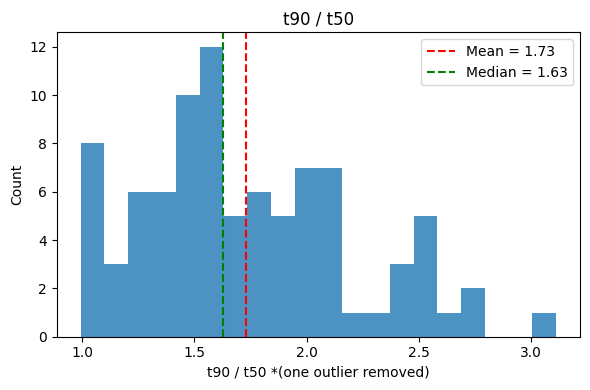

Note: One extreme outlier (ratio ≈ 12.21) was excluded from the plot for clarity.
This outlier likely corresponds to a very long tail recovery relative to initial restoration.


In [24]:
# --- Clean t90/t50 ratio plot with stats and outlier handling ---

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Compute ratio safely
df_ratio = merged_df.copy()
df_ratio = df_ratio.dropna(subset=["t50", "t90_new"])
df_ratio = df_ratio[df_ratio["t50"] > 0]

ratio = df_ratio["t90_new"] / df_ratio["t50"]

# Identify outlier (simple: max value)
outlier_val = ratio.max()

# Remove it for plotting
ratio_clean = ratio[ratio < outlier_val]

# Stats
mean_val = ratio_clean.mean()
median_val = ratio_clean.median()

# Mode (use scipy, but fallback if needed)
mode_val = mode_res.mode[0] if len(mode_res.mode) > 0 else np.nan

# Plot
plt.figure(figsize=(6,4))
plt.hist(ratio_clean, bins=20, alpha=0.8)

# Vertical lines
plt.axvline(mean_val, color="red", linestyle="--", label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, color="green", linestyle="--", label=f"Median = {median_val:.2f}")

plt.xlabel("t90 / t50 *(one outlier removed)")
plt.ylabel("Count")
plt.title("t90 / t50")

plt.legend()
plt.tight_layout()
plt.show()

# Textual statement about outlier
print(f"Note: One extreme outlier (ratio ≈ {outlier_val:.2f}) was excluded from the plot for clarity.")
print("This outlier likely corresponds to a very long tail recovery relative to initial restoration.")

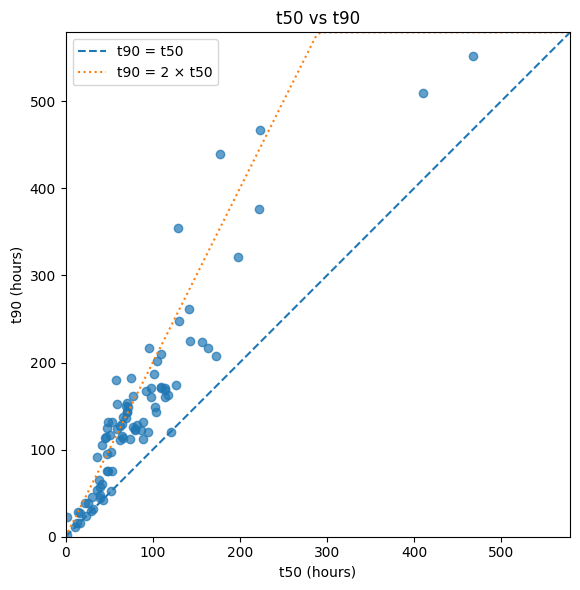

In [15]:
# --- Scatter: t50 vs t90 with equal axes and x2 line ---

import matplotlib.pyplot as plt
import numpy as np

df_plot = merged_df.dropna(subset=["t50", "t90_new"]).copy()

x = df_plot["t50"].values
y = df_plot["t90_new"].values

# Set common axis limit with margin
m = max(x.max(), y.max())
margin = 0.05 * m
limit = m + margin

plt.figure(figsize=(6,6))

# Scatter
plt.scatter(x, y, alpha=0.7)

# 1:1 line
plt.plot([0, limit], [0, limit], "--", label="t90 = t50")

# 2x line (clip to box)
x_line = np.linspace(0, limit, 100)
y_line = 2 * x_line
y_line = np.minimum(y_line, limit)  # clip at top of plot
plt.plot(x_line, y_line, ":", label="t90 = 2 × t50")

# Equal axes
plt.xlim(0, limit)
plt.ylim(0, limit)
plt.gca().set_aspect('equal', adjustable='box')

plt.xlabel("t50 (hours)")
plt.ylabel("t90 (hours)")
plt.title("t50 vs t90")

plt.legend()
plt.tight_layout()
plt.show()

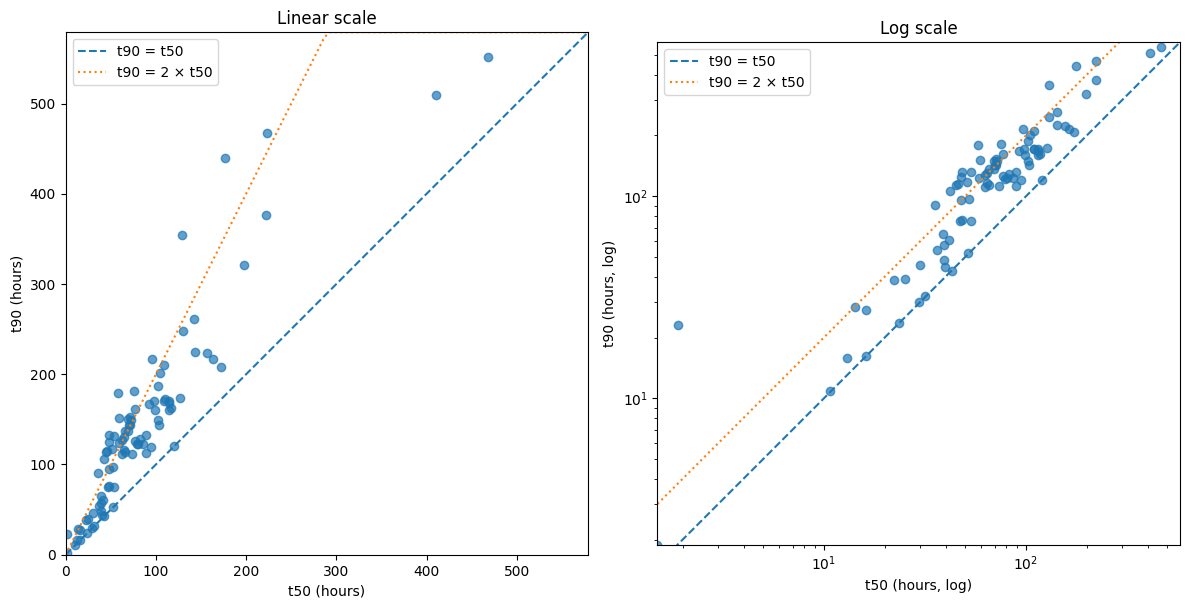

In [21]:
# --- Side-by-side: linear + log scatter ---

import matplotlib.pyplot as plt
import numpy as np

df_plot = merged_df.dropna(subset=["t50", "t90_new"]).copy()

x = df_plot["t50"].values
y = df_plot["t90_new"].values

# ---------- Linear ----------
m = max(x.max(), y.max())
margin = 0.05 * m
limit = m + margin

# ---------- Log (avoid zeros) ----------
mask = (x > 0) & (y > 0)
x_log = x[mask]
y_log = y[mask]

# log limits (use same max but log-transformed)
m_log = max(x_log.max(), y_log.max())
margin_log = 0.05 * m_log
limit_log = m_log + margin_log

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---- LEFT: Linear ----
ax = axes[0]
ax.scatter(x, y, alpha=0.7)

ax.plot([0, limit], [0, limit], "--", label="t90 = t50")

x_line = np.linspace(0, limit, 100)
y_line = np.minimum(2 * x_line, limit)
ax.plot(x_line, y_line, ":", label="t90 = 2 × t50")

ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel("t50 (hours)")
ax.set_ylabel("t90 (hours)")
ax.set_title("Linear scale")
ax.legend()


# ---- RIGHT: Log ----
ax = axes[1]
ax.scatter(x_log, y_log, alpha=0.7)

# Use log axes
ax.set_xscale("log")
ax.set_yscale("log")

# Reference lines (draw in linear then log-transform)
x_line = np.logspace(np.log10(x_log.min()), np.log10(limit_log), 100)

ax.plot(x_line, x_line, "--", label="t90 = t50")
ax.plot(x_line, 2 * x_line, ":", label="t90 = 2 × t50")

ax.set_xlim(x_log.min(), limit_log)
ax.set_ylim(y_log.min(), limit_log)
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel("t50 (hours, log)")
ax.set_ylabel("t90 (hours, log)")
ax.set_title("Log scale")
ax.legend()

plt.tight_layout()
plt.show()

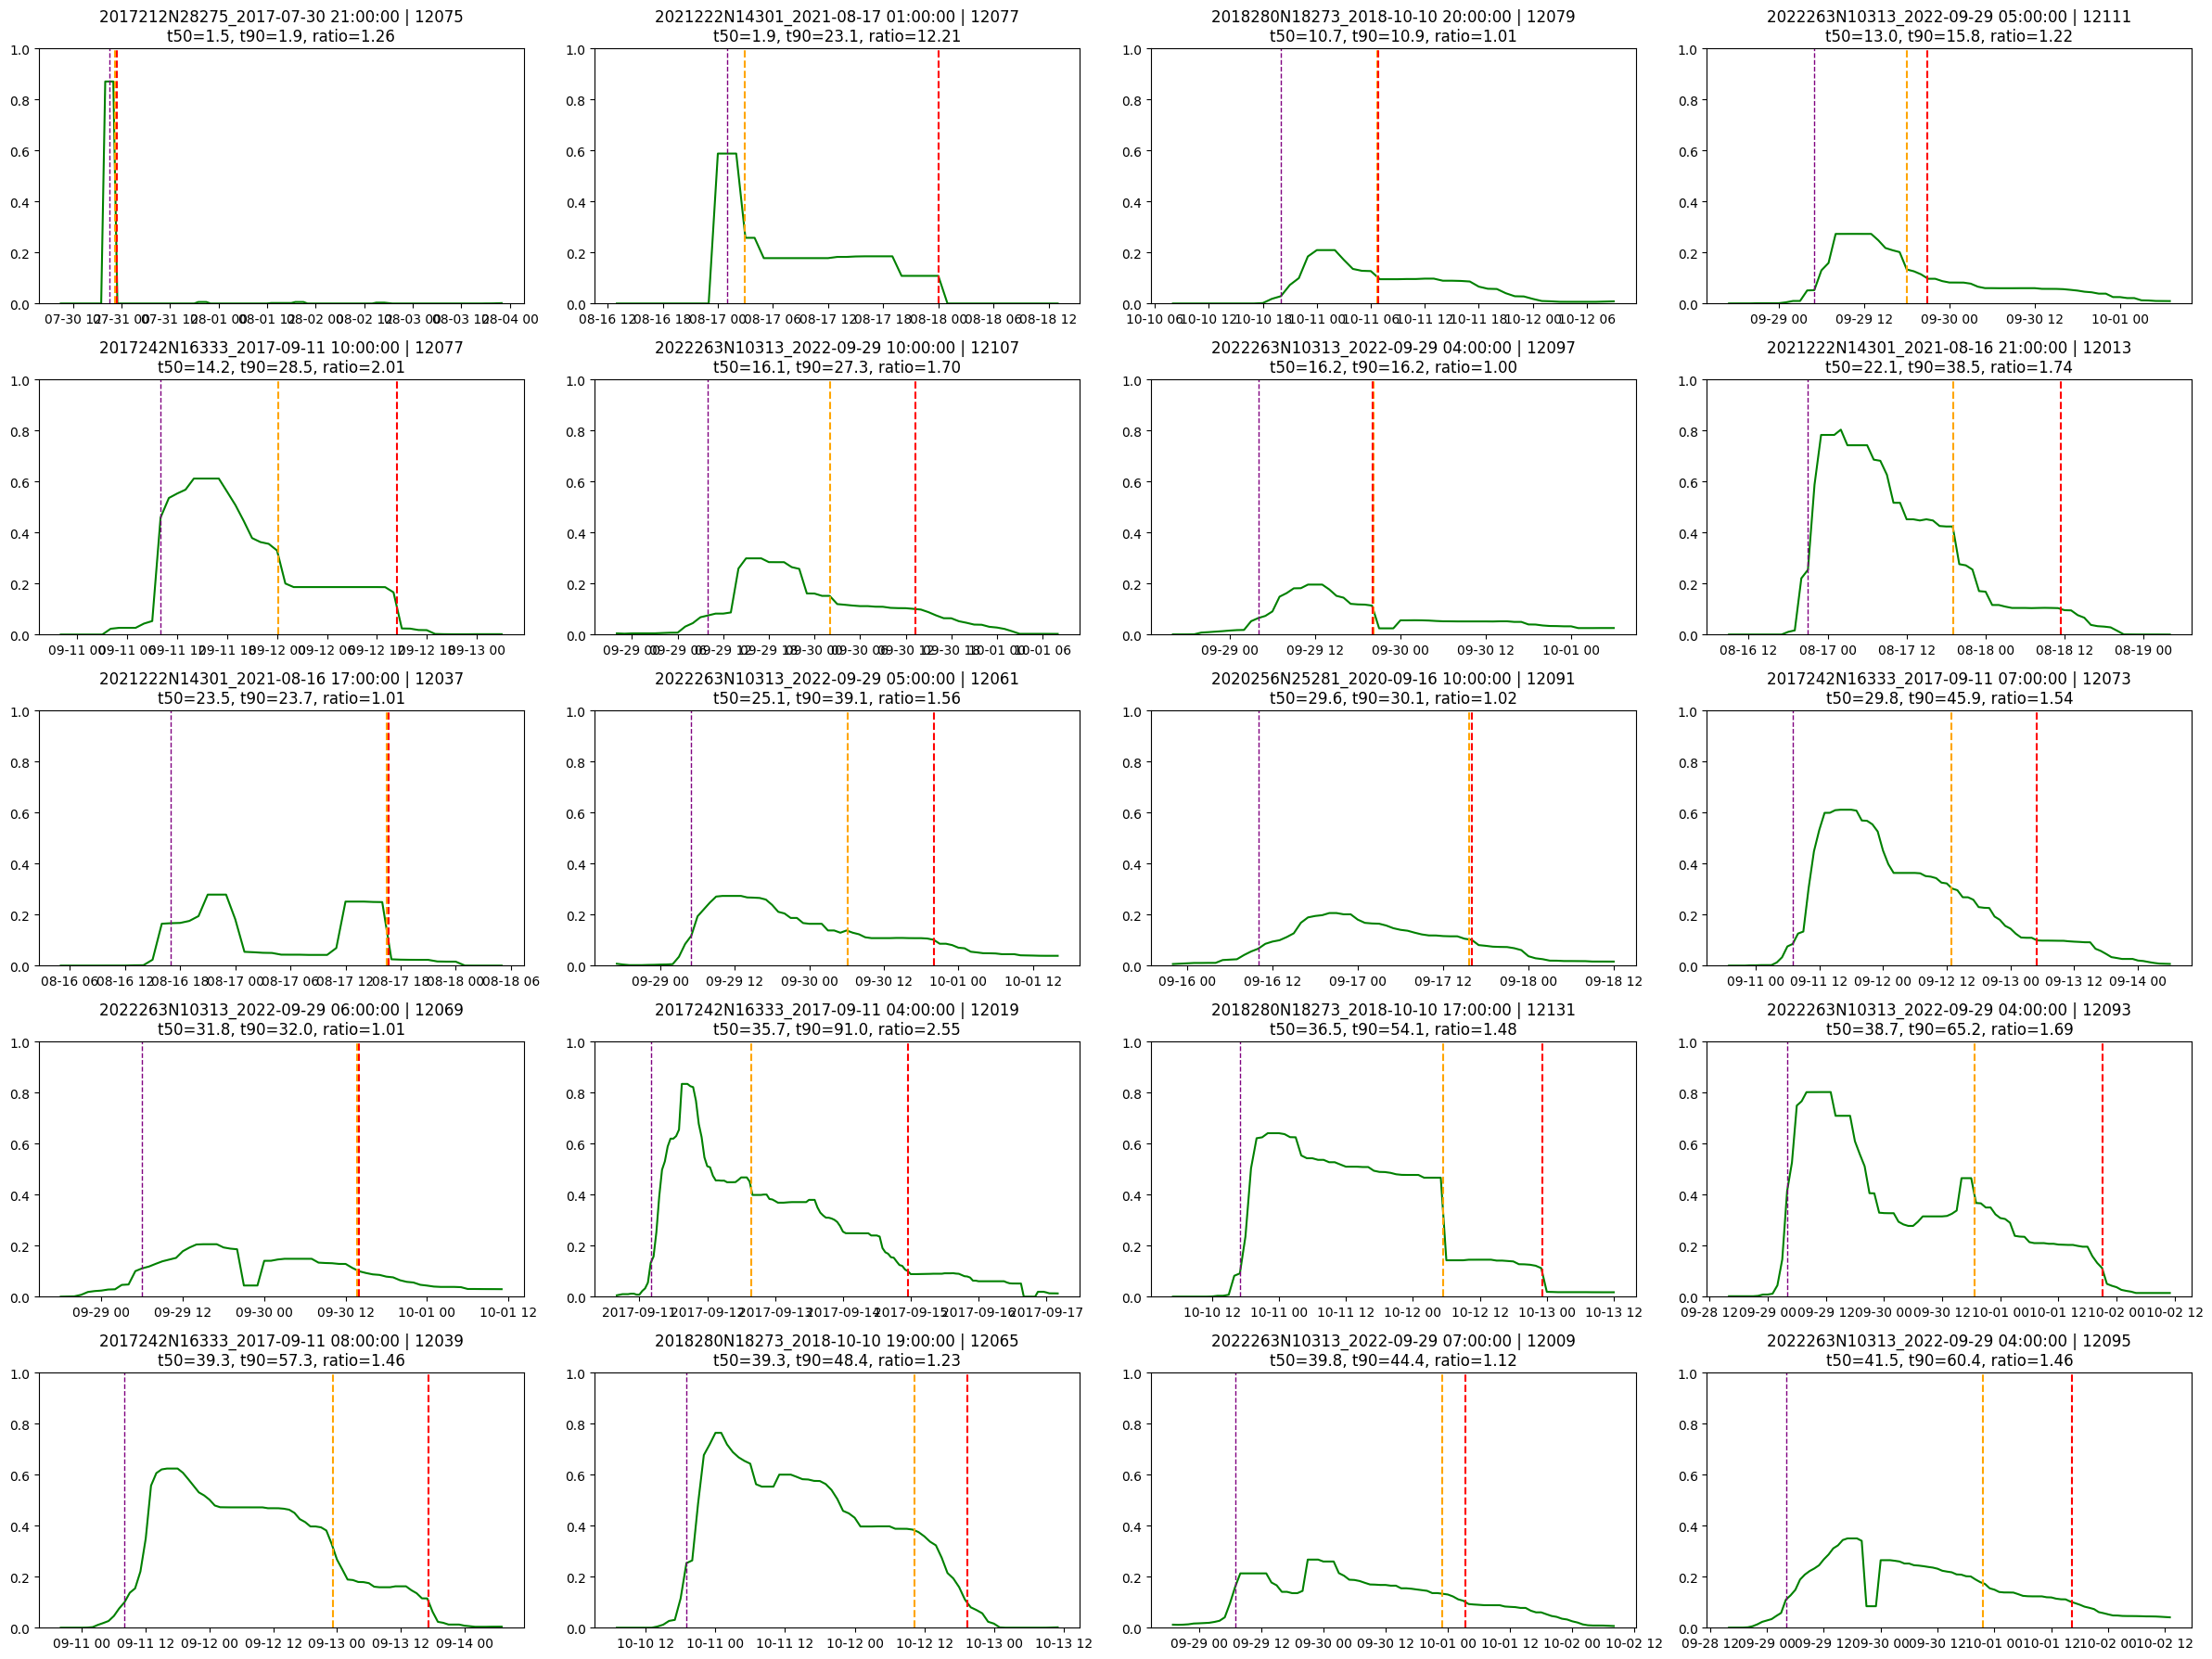

In [20]:
# --- Plot outage curves with t50 and t90 (sorted by t50) ---

import matplotlib.pyplot as plt

plots_per_chunk = 20
chunk = 1

groups = (
    merged_df[["event_id", "CountyFIPS", "t50", "t90_new"]]
    .dropna()
    .sort_values("t50")
    .reset_index(drop=True)
)

start_idx = (chunk - 1) * plots_per_chunk
end_idx = min(start_idx + plots_per_chunk, len(groups))

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, groups.iloc[start_idx:end_idx].iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]
    t50 = row["t50"]
    t90 = row["t90_new"]

    g = ts_df[
        (ts_df["event_id"] == event_id) &
        (ts_df["CountyFIPS"] == county_fips)
    ].sort_values("datetime").copy()

    event_start = g["event_start"].iloc[0]

    ax.set_visible(True)

    # Smoothed outage
    ax.plot(g["datetime"], g["outage_clean"], color="green", linewidth=1.5)

    # --- NEW: event start line ---
    ax.axvline(event_start, color="purple", linestyle="--", linewidth=1)

    # t50 and t90
    ax.axvline(event_start + pd.Timedelta(hours=t50), color="orange", linestyle="--")
    ax.axvline(event_start + pd.Timedelta(hours=t90), color="red", linestyle="--")

    ax.set_title(f"{event_id} | {county_fips}\nt50={t50:.1f}, t90={t90:.1f}, ratio={(t90/t50 if t50 > 0 else np.nan):.2f}")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

^ranked by ascending t90. Realize that some have t90=t50, and it’s even possible for t50>t90:


Definitely not perfect but i've gotta move on.